# 23-liver-epitope-databases

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
warnings.filterwarnings('ignore')
from data.cell_type import annotate_cells

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def read_vdj(path: Path):
  adata = ir.io.read_10x_vdj(path)
  ir.pp.index_chains(adata)
  ir.tl.chain_qc(adata)
  return adata

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData, ad.AnnData]:
  mtx = next(path.glob("*_GEX_matrix.mtx.gz"))
  prefix = mtx.name[: -len("matrix.mtx.gz")]

  adata_gex = sc.read_10x_mtx(path, var_names="gene_symbols", prefix=prefix)
  adata_gex.var_names_make_unique()
  sc.pp.filter_cells(adata_gex, min_genes=200)
  sc.pp.filter_genes(adata_gex, min_cells=3)
  adata_gex.var["mt"] = adata_gex.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(adata_gex, qc_vars=["mt"], inplace=True, log1p=True)
  mu.pp.filter_obs(adata_gex, 'pct_counts_mt', lambda x: x < 10)

  adata_tcr = read_vdj(next(path.glob("*_TCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_tcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_tcr, "chain_pairing", lambda x: x == "single pair")

  adata_bcr = read_vdj(next(path.glob("*_BCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_bcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_bcr, "chain_pairing", lambda x: x == "single pair")

  return adata_gex, adata_tcr, adata_bcr


In [3]:
SAMPLE_RE = re.compile(r"Patient(\d+)-(.+)")

adatas_gex = {}
adatas_tcr = {}
adatas_bcr = {}

for sample_dir in sorted(DATA.glob("*/*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient, condition = match.group(1), match.group(2)
  status = sample_dir.parent.name

  gex, tcr, bcr = read_sample(sample_dir)

  for adata in (gex, tcr, bcr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient
    adata.obs["condition"] = condition
    adata.obs["status"] = status
    adata.obs["pre_transplant"] = status == "Pre-TXP"

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr
  adatas_bcr[sample] = bcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")
adata_bcr = ad.concat(adatas_bcr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "tcr": adata_tcr,
  "bcr": adata_bcr,
})

mdata


MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [4]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.neighbors(mdata['gex'])
sc.tl.umap(mdata['gex'])

In [5]:
annotate_cells(mdata)

🔬 Input data has 7194 cells and 4829 genes
🔗 Matching reference genes in the model
🧬 1005 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'condition' as categorical
... storing 'status' as categorical


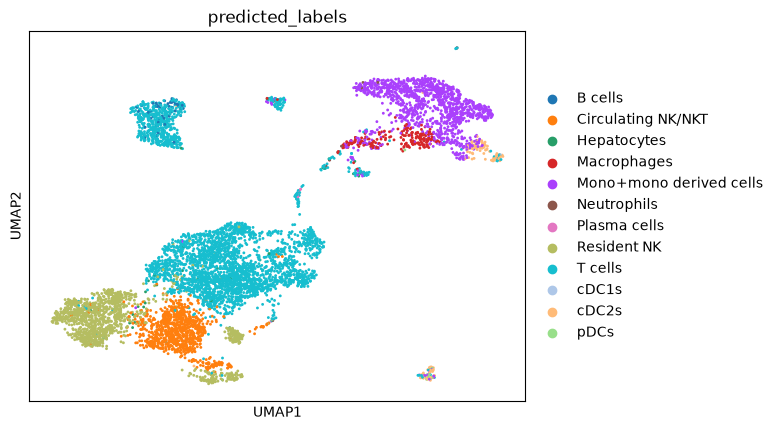

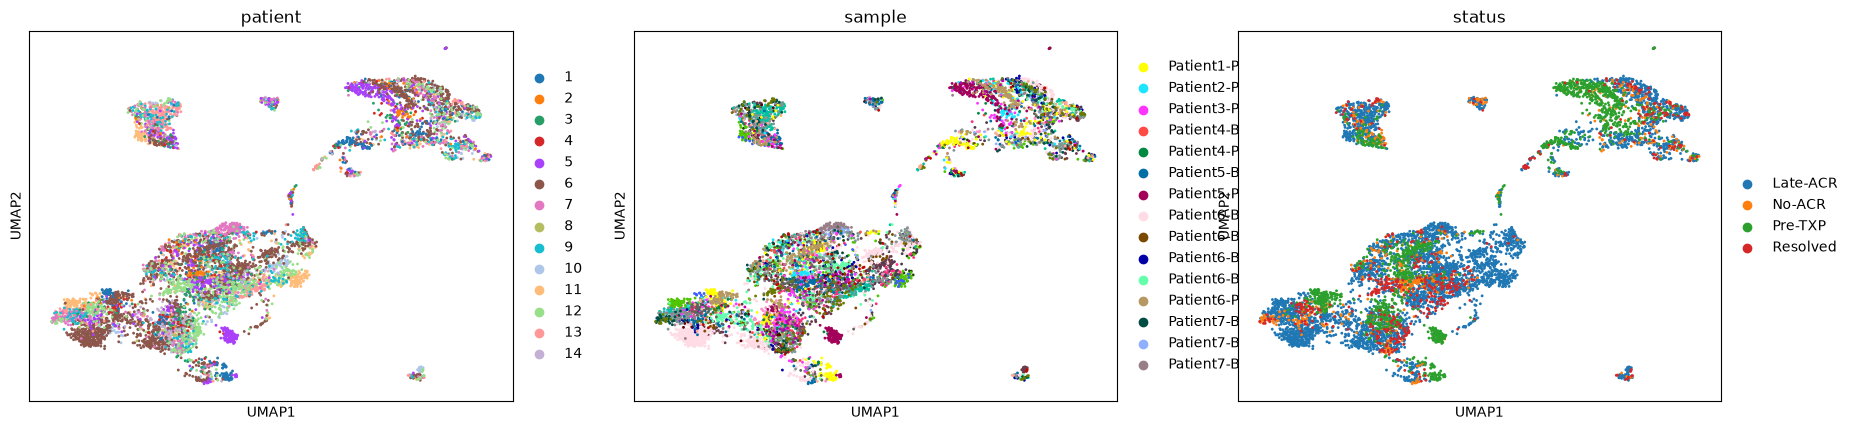

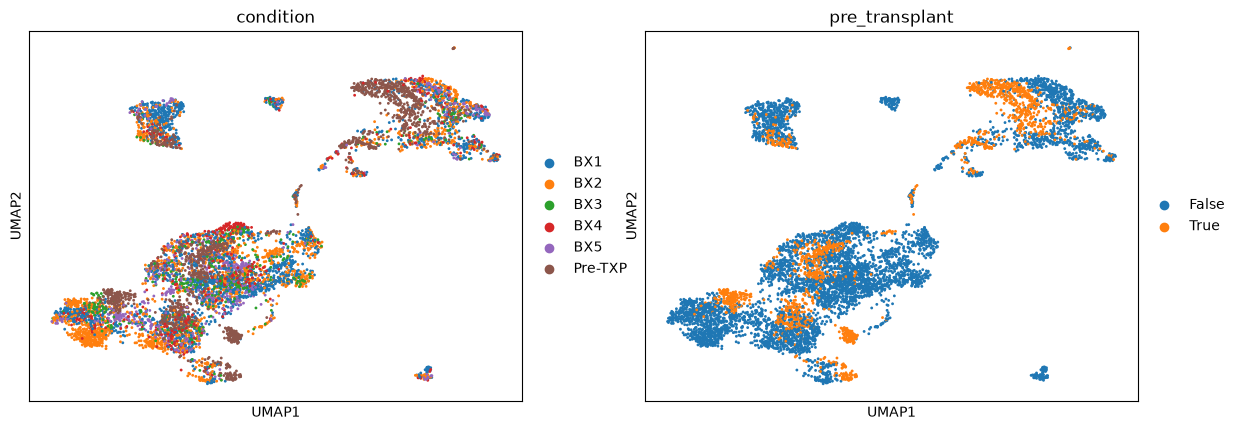

In [6]:
sc.pl.umap(
  mdata['gex'],
  color=["predicted_labels"],
)

sc.pl.umap(
  mdata['gex'],
  color=["patient", "sample", "status"],
)

sc.pl.umap(
  mdata['gex'],
  color=["condition", "pre_transplant"],
)

In [7]:
ir.pp.ir_dist(mdata, airr_mod="tcr")
ir.tl.define_clonotypes(mdata, airr_mod="tcr", receptor_arms="all", dual_ir="primary_only")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'patient_colors', 'sample_colors', 'status_colors', 'condition_colors', 'pre_transplant_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [8]:
ir.pp.ir_dist(
  mdata,
  airr_mod="tcr",
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
)

ir.tl.define_clonotype_clusters(mdata, airr_mod="tcr", sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata, airr_mod="tcr", min_cells=3, sequence="aa", metric="tcrdist")

In [11]:
iggytop = ir.datasets.iggytop()

In [14]:
ir.pp.ir_dist(mdata, iggytop, airr_mod="tcr", metric="identity", sequence="aa")

In [15]:
ir.tl.ir_query(
    mdata,
    iggytop,
    metric="identity",
    airr_mod="tcr",
    sequence="aa",
    receptor_arms="any",
    dual_ir="any",
)

In [17]:
ir.tl.ir_query_annotate(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    airr_mod="tcr",
    include_ref_cols=["antigen_species"],
    strategy="most-frequent",
)

  0%|          | 0/739 [00:00<?, ?it/s]

... storing 'tcr:antigen_species' as categorical


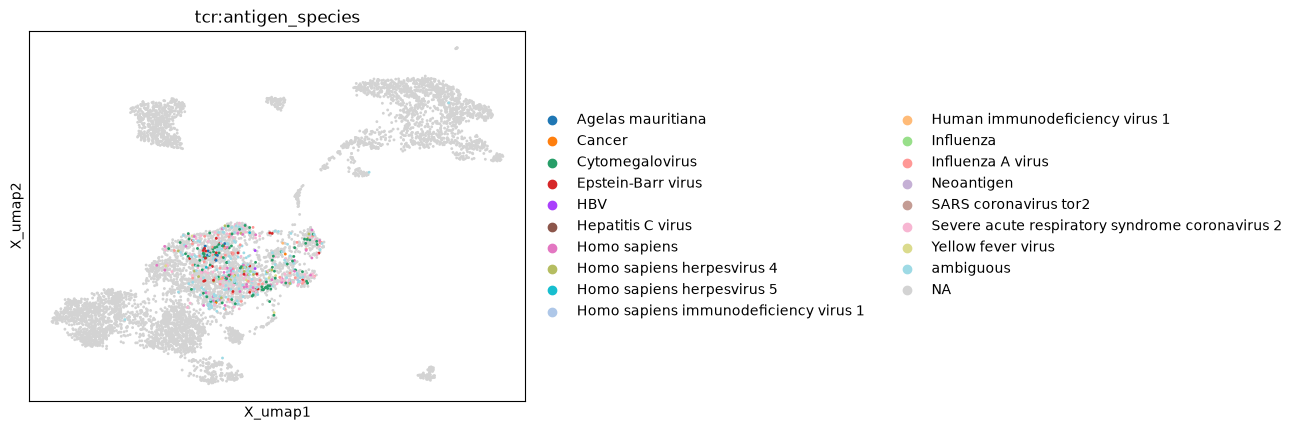

In [18]:
mu.pl.embedding(mdata, "gex:umap", color="tcr:antigen_species")

In [23]:
obs = mdata['tcr'].obs
obs['antigen_species'].value_counts(normalize=True, dropna=False)

antigen_species
NaN                                                0.685249
ambiguous                                          0.098199
Cytomegalovirus                                    0.059605
Severe acute respiratory syndrome coronavirus 2    0.049743
Influenza A virus                                  0.029588
Homo sapiens                                       0.028731
Epstein-Barr virus                                 0.017153
Homo sapiens herpesvirus 4                         0.013722
Yellow fever virus                                 0.005575
Agelas mauritiana                                  0.004717
Cancer                                             0.001286
SARS coronavirus tor2                              0.001286
Influenza                                          0.001286
Human immunodeficiency virus 1                     0.000858
HBV                                                0.000858
Homo sapiens herpesvirus 5                         0.000858
Homo sapiens immunodefic